# Masked Autoencoders Are Scalable Vision Learners — An Annotated Walkthrough

**Paper:** He, Chen, Xie, Li, Dollár, and Girshick. *Masked Autoencoders Are Scalable Vision Learners.* CVPR 2022. [1]

This notebook is an annotated walkthrough of the Masked Autoencoder (MAE), written in the spirit of *The Annotated Transformer*. The goal is to make the paper readable end-to-end: every architectural choice is paired with code, every line of code is paired with an explanation, and every explanation is grounded in the paper itself.

The notebook is organized in three parts:

1. **Background** — why this paper exists, what problem it solves, and what makes its approach unusual.
2. **Model Architecture** — a part-by-part analysis of the model with code, followed by a synthesis diagram that shows how the parts fit together.
3. **Training and Minimal CPU-Ready Example** — the training loop explained piece by piece (loss, optimizer, regularization, schedule), and a miniaturized MAE that actually trains on a laptop CPU so you can watch the whole mechanism work.

A reader who goes through this notebook from top to bottom should come away with a working mental model of MAE, a concrete implementation they can run and modify, and a clear sense of why each design choice in the paper was made.

---

# Part 1 — Background

Before jumping into the architecture, it helps to understand the problem MAE was designed to solve and why earlier approaches struggled with it. This section is not a history lesson — it is the conceptual ground that makes every later design choice feel inevitable rather than arbitrary.

## 1.1 The Problem: Vision Is Hungry for Labels

Modern deep learning models in computer vision are data-hungry in a very specific way: they tend to need *labeled* data. A model like ViT-Large can happily memorize the one million labeled images in ImageNet, and the field has been pushing toward hundreds of millions of labeled images to keep training these large models effectively [1, Sec. 1]. That's expensive, slow, and in many domains simply not possible.

Natural language processing ran into the same wall years earlier, and found a way around it. Methods like BERT and GPT learned to pre-train on *unlabeled* text by hiding part of the input and predicting what was hidden [4]. Once pre-trained, these models transferred beautifully to almost any downstream task. The NLP community had unlocked a scalable way to use the internet's worth of unlabeled text.

The natural question is: *why hasn't the same trick worked as well in vision?* Masked image modeling had been explored before BERT even existed [1, Sec. 2], but the vision version always lagged behind. MAE's central contribution is figuring out exactly why, and then fixing it.

## 1.2 Why Masking Images Is Not Like Masking Text

The paper identifies three reasons the vision version of the idea had been underwhelming. They are worth stating carefully because each one leads directly to a design choice later in the paper [1, Sec. 1].

**1. Architectures used to be mismatched.** For most of deep learning's history, vision was dominated by convolutional networks, which operate on grids of pixels. Masking doesn't fit naturally into that grid view — there's no clean way to say "this patch is hidden, and here's a learnable token that means *hidden*." Transformers treat images as sequences of patches [2], which makes masking straightforward. The architectural obstacle that held vision back is gone.

**2. Images are locally redundant in a way that sentences are not.** If you remove the word *photosynthesis* from a sentence about biology, you cannot recover it by looking at the surrounding words; you need real understanding of the topic. If you remove a small square of blue sky from a photograph, you can almost always fill it in by copying from an adjacent square. This means a *low* masking ratio — the 15% that BERT uses for text — is far too gentle for images. The task becomes trivially solvable by local interpolation, and the model never learns anything interesting. MAE's response is to crank the masking ratio up to 75% or more so that local copying is no longer enough.

**3. The decoder has a different job.** In BERT, the decoder predicts words, which are already high-level semantic objects. A one-layer MLP is enough. In MAE, the decoder predicts pixels, which are low-level. The design of the decoder therefore matters a lot: make it too thin and the encoder is forced to specialize in pixel-level detail; make it appropriately expressive and the encoder is free to learn more abstract features. This asymmetry — a heavy encoder that learns representations and a light decoder that handles pixel reconstruction — is core to MAE.

Each of these three observations becomes a concrete design decision. The rest of the paper is essentially a demonstration that once you address them simultaneously, masked image modeling becomes scalable and effective.

## 1.3 The Key Ideas That Make MAE Work

Against that backdrop, MAE's design can be summarized in two sentences:

1. **Mask a lot of the image** — about 75% of patches — so that reconstruction demands real reasoning, not local copying.
2. **Use an asymmetric encoder-decoder**, where the encoder only sees visible patches and a lightweight decoder handles the rest.

Everything else in the paper follows from these two choices. The high masking ratio makes the task meaningful; the asymmetric design makes the high masking ratio computationally cheap; together they let the authors train very large models on unlabeled images without drowning in compute [1, Sec. 1, Sec. 3].

A few supporting choices are worth naming now because they recur throughout the notebook:

- **Loss only on masked patches.** The encoder is not rewarded for reproducing what it already saw. This focuses the learning signal on inference, not copying [1, Sec. 3].
- **Pixel targets are fine.** MAE reconstructs pixels directly, without needing a separately trained image tokenizer like BEiT [1, Sec. 4.1]. The paper later shows that a simple per-patch normalization of those pixel targets gives a small additional improvement [1, Table 1d].
- **Minimal data augmentation.** Because the random mask changes every iteration, the model already sees a new version of each image on every step. Heavy augmentation, which methods like SimCLR rely on, is not necessary here [1, Table 1e].

The simplicity is the point. MAE doesn't require a tokenizer, a momentum encoder, a contrastive objective, or carefully tuned augmentation. It requires masking and reconstruction, applied at scale.

### A Quick Illustration: Why 75% and Not 15%?

The shift from BERT's 15% masking to MAE's 75% is the single most surprising number in the paper. The figure below sketches the intuition: a sentence loses almost all of its meaning if you remove three out of four words, but an image often survives that kind of removal because of spatial redundancy.

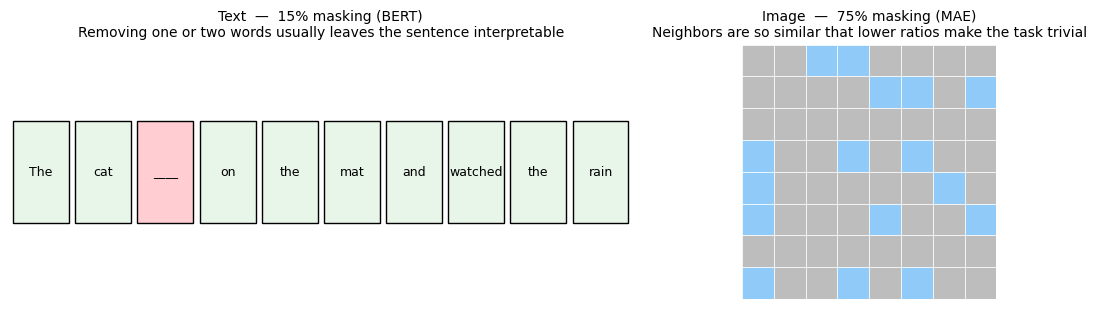

In [1]:
# ------------------------------------------------------------
# A small illustration of the masking-ratio intuition.
# ------------------------------------------------------------
# The point of this cell is not to be pretty, but to make the
# asymmetry between text and images feel concrete before we
# start writing model code.
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(12, 3.2))

# ----- Text side: 15% masking looks almost complete --------------------
words = ["The", "cat", "sat", "on", "the", "mat", "and", "watched", "the", "rain"]
ax = axes[0]
ax.set_xlim(0, len(words))
ax.set_ylim(0, 1)
ax.set_title("Text  —  15% masking (BERT)\n"
             "Removing one or two words usually leaves the sentence interpretable",
             fontsize=10)
mask_word_idx = {2}  # mask one word out of ten
for i, w in enumerate(words):
    color = "#FFCDD2" if i in mask_word_idx else "#E8F5E9"
    ax.add_patch(mpatches.Rectangle((i + 0.05, 0.3), 0.9, 0.4,
                                    facecolor=color, edgecolor="black"))
    label = "____" if i in mask_word_idx else w
    ax.text(i + 0.5, 0.5, label, ha="center", va="center", fontsize=9)
ax.axis("off")

# ----- Vision side: 75% masking of an 8x8 patch grid -------------------
ax = axes[1]
grid = 8
rng = np.random.default_rng(0)
num_patches = grid * grid
num_masked = int(0.75 * num_patches)
masked = set(rng.choice(num_patches, size=num_masked, replace=False).tolist())
for idx in range(num_patches):
    r, c = divmod(idx, grid)
    color = "#BDBDBD" if idx in masked else "#90CAF9"
    ax.add_patch(mpatches.Rectangle((c, grid - 1 - r), 1, 1,
                                    facecolor=color, edgecolor="white", linewidth=0.5))
ax.set_xlim(0, grid)
ax.set_ylim(0, grid)
ax.set_aspect("equal")
ax.set_title("Image  —  75% masking (MAE)\n"
             "Neighbors are so similar that lower ratios make the task trivial",
             fontsize=10)
ax.axis("off")

plt.tight_layout()
plt.show()

The takeaway is qualitative: *the same masking ratio cannot work for both modalities*, because they have very different information densities. MAE chooses its ratio to match the medium, and from that one decision the rest of the architecture follows.

## 1.4 Why This Paper Matters Beyond the Benchmark

It would be easy to read MAE as "a new pre-training trick that scored well on ImageNet." That would undersell it. The deeper message is that computer vision has a simple, scalable self-supervised recipe that mirrors what worked in NLP:

- **No labels needed during pre-training.** Unlabeled images are effectively free at internet scale.
- **The encoder becomes a reusable general-purpose feature extractor.** Once pre-trained, it transfers to classification, object detection, and segmentation, often beating supervised pre-training [1, Sec. 5].
- **Bigger models keep getting better.** MAE's gains grow with model capacity — ViT-Huge reaches 87.8% on ImageNet-1K using only ImageNet-1K data [1, Sec. 4.2], outperforming methods that used far more data.

Self-supervised learning in vision was crowded, complicated, and dominated by contrastive methods before this paper. MAE argued — and demonstrated — that a plain autoencoder, done carefully, is both simpler and more scalable. That is an unusually clean result in an area that tends to accumulate tricks.

With the motivation in place, the rest of the notebook turns to the how. Part 2 opens the architecture up piece by piece, and Part 3 walks through the training loop.

---

# Part 2 — Model Architecture

This part opens the model up and explains each component with code. We follow the data flow that Figure 1 of the paper depicts: image → patches → masking → encoder → decoder → reconstruction [1, Fig. 1].

The structure of this section is:

- **2.1 Setup** — imports, hyperparameters, and a note on why the mini configuration is a faithful scale-down.
- **2.2 Architecture diagram** — a visual roadmap so the reader knows where each component sits before seeing its code.
- **2.3–2.8 Part-by-part analysis** — patchification, masking, transformer blocks, encoder, decoder, loss.
- **2.9 Synthesis** — the full `MiniMAE` class that binds the parts together, plus a forward-pass walkthrough with concrete tensor shapes.

The goal is to reach the end of this part with a model that is both complete and completely transparent.

## 2.1 Setup

We import the libraries we will use throughout the notebook, fix random seeds for reproducibility, and pin the device to CPU so the same code runs identically on a laptop.

In [2]:
# ------------------------------------------------------------
# Imports
# ------------------------------------------------------------
# We use PyTorch for the model. Everything else (numpy,
# matplotlib) is for visualization and diagnostics. Keeping the
# dependency surface small makes the notebook easier to run.
import math
import time
import random
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------
# Fixed seeds keep plots and training curves consistent across runs,
# which makes the notebook easier to read and review.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# ------------------------------------------------------------
# Device
# ------------------------------------------------------------
# The project requires a CPU-runnable example. We pin to CPU on
# purpose so that any reader can execute this notebook end-to-end
# without worrying about CUDA, MPS, or driver versions.
device = torch.device("cpu")
print("Using device:", device)

Using device: cpu


### Mini-configuration hyperparameters

Every number below is deliberately smaller than the paper's counterpart. The goal is not to reproduce ImageNet-level accuracy — it is to fit a faithful copy of the MAE mechanism into a laptop's memory and time budget, so the reader can actually run it and watch the loss go down. Each value is annotated with the paper's equivalent so the scale-down is transparent.

In [3]:
# ------------------------------------------------------------
# Miniaturized hyperparameters
# ------------------------------------------------------------
# On the right we note what the original paper uses for ViT-Large
# on ImageNet, so the degree of simplification is visible at a glance.
IMAGE_SIZE        = 32     # CIFAR-10 32x32            (paper: 224x224 ImageNet)
PATCH_SIZE        = 4      # 8x8 = 64 patches per image (paper: 16x16 patches)
IN_CHANNELS       = 3
NUM_PATCHES       = (IMAGE_SIZE // PATCH_SIZE) ** 2    # 64
PATCH_DIM         = PATCH_SIZE * PATCH_SIZE * IN_CHANNELS  # 48 floats per patch

EMBED_DIM         = 128    # encoder width             (paper ViT-L: 1024)
ENCODER_DEPTH     = 2      # encoder blocks            (paper ViT-L: 24)
DECODER_EMBED_DIM = 96     # decoder width             (paper: 512)
DECODER_DEPTH     = 2      # decoder blocks            (paper: 8)
NUM_HEADS         = 4      # attention heads           (paper: 16)

MASK_RATIO        = 0.75   # matches the paper exactly [1, Fig. 5]
BATCH_SIZE        = 64
EPOCHS            = 5      # paper uses 800-1600 epochs on full ImageNet
LEARNING_RATE     = 1e-3

WEIGHT_DECAY      = 0.05   # AdamW weight decay        [1, App. A.1]
WARMUP_EPOCHS     = 1      # linear warmup then cosine  [1, App. A.1, Sec. 3.5]
NORM_PIX_LOSS     = True   # per-patch target normalization [1, Table 1d]

print(f"Patches per image: {NUM_PATCHES}")
print(f"Flattened patch dimension: {PATCH_DIM}")
print(f"Visible patches after masking ({int(MASK_RATIO*100)}%): "
      f"{int(NUM_PATCHES * (1 - MASK_RATIO))}")

Patches per image: 64
Flattened patch dimension: 48
Visible patches after masking (75%): 16


At this scale a forward pass on a batch of 64 images costs roughly a tenth of a second on a laptop CPU, which is more than fast enough for a five-epoch training run over a 5 000-image subset of CIFAR-10.

A few places where we deliberately simplify relative to the full paper are worth flagging up front:

- **Learned positional embeddings** instead of the 2D sinusoidal ones used in the paper. The paper shows both work; learned embeddings are one fewer page of code to read.
- **No `[CLS]` token.** MAE inherits this from ViT, but pre-training never uses it — it only matters for downstream classification, which is out of scope for the MWE.
- **AdamW with warmup + cosine decay.** We use AdamW with `betas=(0.9, 0.95)` and `weight_decay=0.05`, plus a one-epoch linear warmup followed by cosine decay to zero. These are the same optimizer and schedule choices the paper uses at full scale [1, App. A.1], scaled down to a five-epoch run — we explain each piece in Part 3.
- **Per-patch-normalized pixel targets.** We set `norm_pix_loss=True`, matching the variant in Table 1d of the paper [1, Table 1d] that slightly improves representation quality. The loss is computed against the z-scored patch; the reconstructions in Section 3.10 un-normalize before display.

None of these simplifications change the behavior the notebook is meant to demonstrate. They trade a little accuracy for a lot of readability.

## 2.2 Architecture Diagram — The Whole Pipeline in One Picture

Before we start building, here is the whole data flow in one figure. Each box is a stage, each arrow is labeled with the tensor shape that flows across it, and the colors group the stages by role (input handling in blue, masking in orange, encoder in green, decoder in pink, loss in purple).

Read this once before the part-by-part analysis below — it will make the individual pieces much easier to place. We will return to this diagram in the synthesis section (2.9) after every component has been implemented.

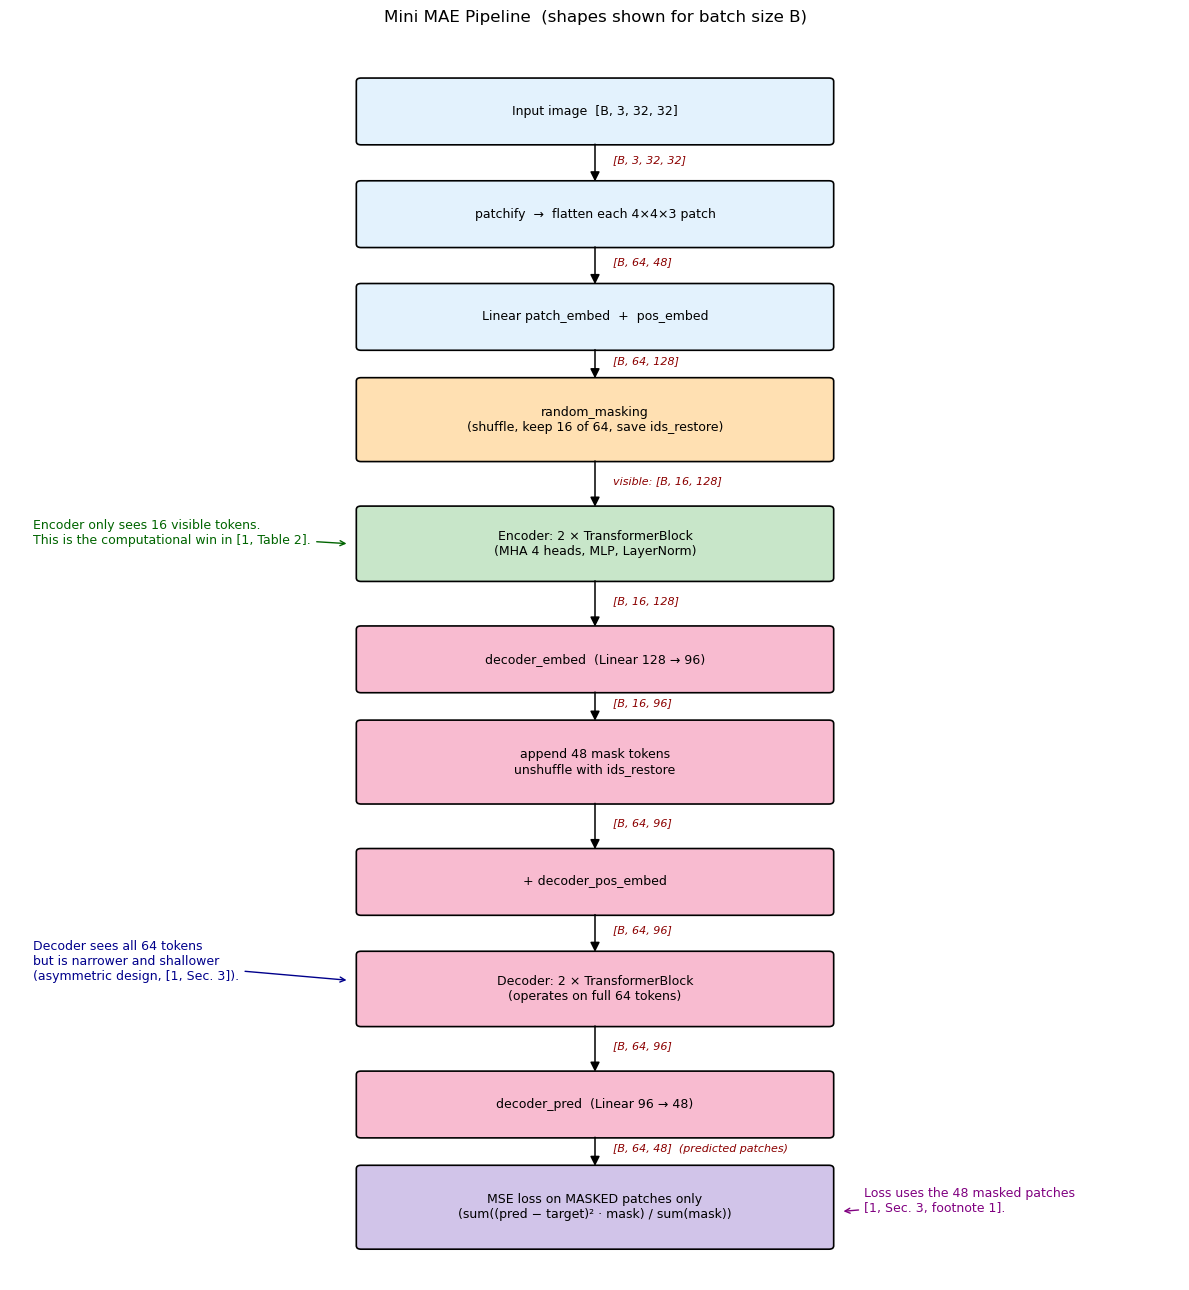

In [4]:
# ------------------------------------------------------------
# Pipeline diagram
# ------------------------------------------------------------
# This mirrors Figure 1 of [1] but labels every arrow with the
# concrete tensor shapes for our mini configuration, which helps
# ground the later code in something you can point at.

def _box(ax, x, y, w, h, text, color):
    ax.add_patch(FancyBboxPatch(
        (x, y), w, h, boxstyle="round,pad=0.04",
        facecolor=color, edgecolor="black", linewidth=1.2
    ))
    ax.text(x + w / 2, y + h / 2, text,
            ha="center", va="center", fontsize=9)

def _arrow(ax, x1, y1, x2, y2, label=None):
    ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle="-|>", lw=1.1,
                                color="black", mutation_scale=14))
    if label is not None:
        ax.text((x1 + x2) / 2 + 0.15, (y1 + y2) / 2,
                label, fontsize=8, color="darkred", style="italic")

fig, ax = plt.subplots(figsize=(12, 13))
ax.set_xlim(0, 10); ax.set_ylim(0, 14.5); ax.axis("off")

INPUT_C, MASK_C, ENC_C, DEC_C, LOSS_C = (
    "#E3F2FD", "#FFE0B2", "#C8E6C9", "#F8BBD0", "#D1C4E9"
)

cx1, cx2 = 3.0, 7.0
w = cx2 - cx1
cxm = (cx1 + cx2) / 2

_box(ax, cx1, 13.3, w, 0.7, "Input image  [B, 3, 32, 32]", INPUT_C)
_box(ax, cx1, 12.1, w, 0.7, "patchify  →  flatten each 4×4×3 patch", INPUT_C)
_box(ax, cx1, 10.9, w, 0.7, "Linear patch_embed  +  pos_embed", INPUT_C)
_box(ax, cx1,  9.6, w, 0.9, "random_masking\n(shuffle, keep 16 of 64, save ids_restore)", MASK_C)
_box(ax, cx1,  8.2, w, 0.8, "Encoder: 2 × TransformerBlock\n(MHA 4 heads, MLP, LayerNorm)", ENC_C)
_box(ax, cx1,  6.9, w, 0.7, "decoder_embed  (Linear 128 → 96)", DEC_C)
_box(ax, cx1,  5.6, w, 0.9, "append 48 mask tokens\nunshuffle with ids_restore", DEC_C)
_box(ax, cx1,  4.3, w, 0.7, "+ decoder_pos_embed", DEC_C)
_box(ax, cx1,  3.0, w, 0.8, "Decoder: 2 × TransformerBlock\n(operates on full 64 tokens)", DEC_C)
_box(ax, cx1,  1.7, w, 0.7, "decoder_pred  (Linear 96 → 48)", DEC_C)
_box(ax, cx1,  0.4, w, 0.9, "MSE loss on MASKED patches only\n(sum((pred − target)² · mask) / sum(mask))", LOSS_C)

_arrow(ax, cxm, 13.3, cxm, 12.8, "[B, 3, 32, 32]")
_arrow(ax, cxm, 12.1, cxm, 11.6, "[B, 64, 48]")
_arrow(ax, cxm, 10.9, cxm, 10.5, "[B, 64, 128]")
_arrow(ax, cxm,  9.6, cxm,  9.0, "visible: [B, 16, 128]")
_arrow(ax, cxm,  8.2, cxm,  7.6, "[B, 16, 128]")
_arrow(ax, cxm,  6.9, cxm,  6.5, "[B, 16, 96]")
_arrow(ax, cxm,  5.6, cxm,  5.0, "[B, 64, 96]")
_arrow(ax, cxm,  4.3, cxm,  3.8, "[B, 64, 96]")
_arrow(ax, cxm,  3.0, cxm,  2.4, "[B, 64, 96]")
_arrow(ax, cxm,  1.7, cxm,  1.3, "[B, 64, 48]  (predicted patches)")

ax.annotate("Encoder only sees 16 visible tokens.\n"
            "This is the computational win in [1, Table 2].",
            xy=(cx1 - 0.1, 8.6), xytext=(0.2, 8.6),
            fontsize=9, color="darkgreen",
            arrowprops=dict(arrowstyle="->", lw=1.0, color="darkgreen"))
ax.annotate("Decoder sees all 64 tokens\n"
            "but is narrower and shallower\n"
            "(asymmetric design, [1, Sec. 3]).",
            xy=(cx1 - 0.1, 3.5), xytext=(0.2, 3.5),
            fontsize=9, color="darkblue",
            arrowprops=dict(arrowstyle="->", lw=1.0, color="darkblue"))
ax.annotate("Loss uses the 48 masked patches\n"
            "[1, Sec. 3, footnote 1].",
            xy=(cx2 + 0.1, 0.8), xytext=(cx2 + 0.3, 0.8),
            fontsize=9, color="purple",
            arrowprops=dict(arrowstyle="->", lw=1.0, color="purple"))

ax.set_title("Mini MAE Pipeline  (shapes shown for batch size B)",
             fontsize=12, pad=12)
plt.tight_layout()
plt.show()

With the road map in hand, we now walk down it. The next subsections implement each component in isolation and explain what it does and why it is shaped the way it is.

## 2.3 Patchification — From an Image to a Sequence of Patches

MAE inherits its basic input representation from the Vision Transformer [2]: an image is cut into non-overlapping square patches, and each patch is flattened into a vector. That sequence of vectors is the input the rest of the model sees.

Two helpers make this operation explicit and reversible:

- `patchify` reshapes `[B, C, H, W]` into `[B, N, patch_dim]`, where `N` is the number of patches per image.
- `unpatchify` does the inverse, so we can turn predicted patches back into an image for visualization.

Masking in MAE happens at the patch level, not the pixel level — once we have this representation, the rest of the model works on sequences of tokens just like a language model would [1, Sec. 3].

In [5]:
# ------------------------------------------------------------
# patchify  /  unpatchify
# ------------------------------------------------------------
# We keep these as plain tensor reshapes rather than using
# nn.Unfold. The explicit reshape path is slower but much easier
# to read and to compare against the paper's notation.

def patchify(images, patch_size=PATCH_SIZE):
    """[B, C, H, W]  ->  [B, N, patch_dim]"""
    B, C, H, W = images.shape
    assert H % patch_size == 0 and W % patch_size == 0, \
        "Image size must be divisible by patch size"
    hp = H // patch_size
    wp = W // patch_size
    patches = images.reshape(B, C, hp, patch_size, wp, patch_size)
    patches = patches.permute(0, 2, 4, 1, 3, 5)       # [B, hp, wp, C, p, p]
    patches = patches.reshape(B, hp * wp, C * patch_size * patch_size)
    return patches


def unpatchify(patches, patch_size=PATCH_SIZE,
               image_size=IMAGE_SIZE, channels=IN_CHANNELS):
    """[B, N, patch_dim]  ->  [B, C, H, W]"""
    B, N, D = patches.shape
    hp = image_size // patch_size
    wp = image_size // patch_size
    assert N == hp * wp, "Patch count does not match target image size"
    images = patches.reshape(B, hp, wp, channels, patch_size, patch_size)
    images = images.permute(0, 3, 1, 4, 2, 5)         # [B, C, hp, p, wp, p]
    images = images.reshape(B, channels, image_size, image_size)
    return images


# Round-trip sanity check: patchify then unpatchify should be exact.
_probe = torch.randn(2, IN_CHANNELS, IMAGE_SIZE, IMAGE_SIZE)
assert torch.allclose(_probe, unpatchify(patchify(_probe)))
print(f"patchify:    [B,C,H,W] → [B,{NUM_PATCHES},{PATCH_DIM}]")
print(f"unpatchify:  [B,{NUM_PATCHES},{PATCH_DIM}] → [B,C,H,W]")
print("Round-trip reconstruction is exact. ✓")

patchify:    [B,C,H,W] → [B,64,48]
unpatchify:  [B,64,48] → [B,C,H,W]
Round-trip reconstruction is exact. ✓


The round-trip assertion is there to reassure the reader that `unpatchify(patchify(x)) == x`, which means when the decoder later produces `[B, N, patch_dim]` we can safely fold it back into an image for inspection. No information is lost or reordered in the conversion.

## 2.4 Random Masking — The Shuffle/Keep/Unshuffle Trick

Now for the operation that makes MAE *MAE*: we randomly hide most of the patches before the encoder sees them.

Implementing this naively — say, by multiplying patches by a 0/1 mask — would force the encoder to look at every patch anyway, just with a lot of zeros. That defeats the whole point of the asymmetric design. Instead, the paper uses an elegant index-shuffling trick [1, Sec. 3, "Simple implementation"]:

1. Draw a random permutation of patch indices for each image in the batch.
2. Keep the first `len_keep = N · (1 − r)` patches — these are the *visible* ones that go into the encoder.
3. Remember the inverse permutation so that after the encoder we can drop mask tokens into the correct holes.

The encoder works on a genuinely shorter sequence — in our case 16 tokens instead of 64 — which is where the real speed and memory gain comes from. No sparse operations are required, and the implementation is a handful of `torch.argsort` and `torch.gather` calls.

In [6]:
# ------------------------------------------------------------
# random_masking
# ------------------------------------------------------------
# This function is short, but worth reading slowly. It implements
# the shuffle/keep/unshuffle pattern from the paper. The returned
# `ids_restore` tensor is the key: it is the recipe for putting the
# missing patches back in the right places after encoding.

def random_masking(x, mask_ratio=MASK_RATIO):
    """
    x: [B, N, D] -- patch embeddings in original spatial order.
    returns
        x_visible   : [B, len_keep, D]   kept patches in shuffled order
        mask        : [B, N]             1.0 at masked positions, 0.0 elsewhere
        ids_restore : [B, N]             indices to unshuffle back to original order
        ids_keep    : [B, len_keep]      original indices of visible patches
    """
    B, N, D = x.shape
    len_keep = int(N * (1 - mask_ratio))

    # Step 1: assign each patch a random score per image.
    noise = torch.rand(B, N, device=x.device)

    # Step 2: sort to get a random permutation, then invert it so
    # we can later go from "shuffled order" back to "original order".
    ids_shuffle = torch.argsort(noise, dim=1)         # [B, N]
    ids_restore = torch.argsort(ids_shuffle, dim=1)   # [B, N]

    # Step 3: keep the first len_keep shuffled indices.
    ids_keep = ids_shuffle[:, :len_keep]              # [B, len_keep]
    x_visible = torch.gather(
        x, dim=1,
        index=ids_keep.unsqueeze(-1).expand(-1, -1, D)
    )

    # Step 4: build the binary mask in the ORIGINAL patch order.
    # In shuffled order, positions [0:len_keep] are visible and
    # [len_keep:] are masked — we unshuffle that pattern.
    mask = torch.ones(B, N, device=x.device)
    mask[:, :len_keep] = 0
    mask = torch.gather(mask, dim=1, index=ids_restore)

    return x_visible, mask, ids_restore, ids_keep


# Quick numerical check: the fraction of masked patches matches MASK_RATIO.
_probe = torch.randn(4, NUM_PATCHES, EMBED_DIM)
_vis, _mask, _ids_restore, _ids_keep = random_masking(_probe, MASK_RATIO)
print(f"Visible tokens per image: {_vis.shape[1]} / {NUM_PATCHES} "
      f"({100 * _vis.shape[1] / NUM_PATCHES:.0f}% kept)")
print(f"Masked fraction (averaged over batch): "
      f"{_mask.mean().item():.3f}  (target: {MASK_RATIO})")

Visible tokens per image: 16 / 64 (25% kept)
Masked fraction (averaged over batch): 0.750  (target: 0.75)


### Visualizing what the encoder actually sees

The code above speaks in indices. It is worth converting that back to an image so the reader can see what 75% masking looks like on an actual CIFAR-10 sample: the encoder only gets the colored squares.

In [7]:
# ------------------------------------------------------------
# Load a small image dataset for visualizations and training.
# ------------------------------------------------------------
# We try CIFAR-10 first because it is the standard small real-world
# dataset for this kind of demo [5]. If the CIFAR-10 download fails
# (for example on an offline or firewalled machine), we fall back
# to a small synthetic dataset that preserves the 32x32 RGB shape.
# The MAE mechanism is identical in either case -- the model sees
# 32x32x3 images, splits them into patches, and learns to reconstruct.

transform = transforms.Compose([transforms.ToTensor()])

def _make_synthetic_dataset(n=5000, size=IMAGE_SIZE):
    # Generate synthetic images with smooth low-frequency structure
    # so they have local spatial redundancy similar to real images.
    # The point is not photorealism -- it is that the MAE pretext
    # task is non-trivial on this data.
    rng = np.random.default_rng(0)
    imgs = []
    xs = np.linspace(0, 1, size)
    ys = np.linspace(0, 1, size)
    xx, yy = np.meshgrid(xs, ys)
    for _ in range(n):
        freqs = rng.uniform(1.5, 6.0, size=6)
        phases = rng.uniform(0, 2 * np.pi, size=6)
        r = 0.5 + 0.25 * np.sin(freqs[0] * xx + phases[0]) * np.cos(freqs[1] * yy + phases[1])
        g = 0.5 + 0.25 * np.sin(freqs[2] * xx + phases[2]) * np.cos(freqs[3] * yy + phases[3])
        b = 0.5 + 0.25 * np.sin(freqs[4] * xx + phases[4]) * np.cos(freqs[5] * yy + phases[5])
        im = np.stack([r, g, b], axis=0).clip(0, 1).astype(np.float32)
        imgs.append(torch.from_numpy(im))
    class _Synth(torch.utils.data.Dataset):
        def __init__(self, data): self.data = data
        def __len__(self): return len(self.data)
        def __getitem__(self, i): return self.data[i], 0
    return _Synth(imgs)

try:
    train_dataset = datasets.CIFAR10(root="./data", train=True,
                                      download=True, transform=transform)
    train_subset = Subset(train_dataset, list(range(5000)))
    dataset_name = "CIFAR-10 (5000-image subset)"
except Exception as e:
    print(f"CIFAR-10 unavailable ({type(e).__name__}); using synthetic fallback.")
    train_subset = _make_synthetic_dataset(n=5000)
    dataset_name = "Synthetic 32x32 RGB (5000 images)"

train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True)
sample_batch, _ = next(iter(train_loader))
print(f"Dataset: {dataset_name}")
print(f"Sample batch shape: {tuple(sample_batch.shape)}")

Dataset: CIFAR-10 (5000-image subset)
Sample batch shape: (64, 3, 32, 32)


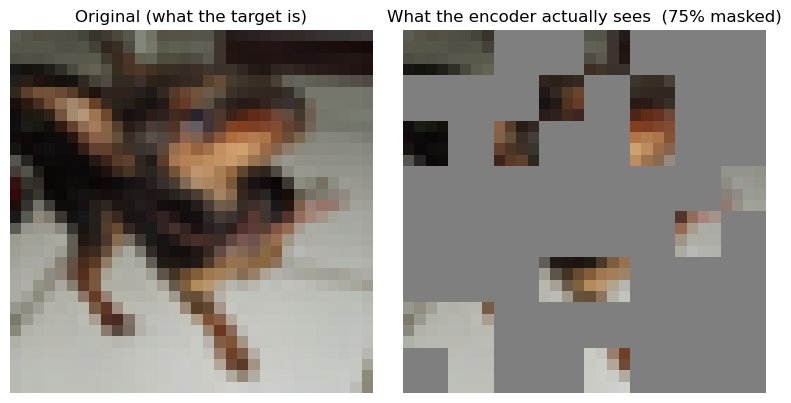

In [8]:
# ------------------------------------------------------------
# Render a masked image so the reader can see what the encoder
# actually receives: 16 out of 64 patches, chosen uniformly at random.
# ------------------------------------------------------------

def apply_patch_mask_to_image(image, mask, patch_size=PATCH_SIZE):
    """Paint masked patches gray for display purposes only."""
    image = image.clone()
    _, H, W = image.shape
    hp, wp = H // patch_size, W // patch_size
    idx = 0
    for i in range(hp):
        for j in range(wp):
            if mask[idx] == 1:
                image[:, i*patch_size:(i+1)*patch_size,
                         j*patch_size:(j+1)*patch_size] = 0.5
            idx += 1
    return image


example_img = sample_batch[0:1]
_dummy_tokens = torch.randn(1, NUM_PATCHES, EMBED_DIM)
_, demo_mask, _, _ = random_masking(_dummy_tokens, MASK_RATIO)
masked_image = apply_patch_mask_to_image(example_img[0], demo_mask[0])

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(np.transpose(example_img[0].numpy(), (1, 2, 0)))
plt.title("Original (what the target is)"); plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(np.transpose(masked_image.numpy(), (1, 2, 0)))
plt.title(f"What the encoder actually sees  ({int(MASK_RATIO*100)}% masked)")
plt.axis("off")
plt.tight_layout()
plt.show()

That gray-speckled image is a real depiction of the pre-training task. The encoder is handed only the colored tiles and, via the decoder, has to produce a plausible reconstruction of everything that was hidden. At this masking level "plausible" cannot mean "copied from the neighbors" — most neighbors are missing too. The model has to learn something about the structure of natural images.

## 2.5 Transformer Block — The Shared Building Brick

Both the encoder and the decoder are stacks of identical Transformer blocks [3]. A block has two sub-layers: multi-head self-attention and a two-layer MLP, each wrapped in a LayerNorm and a residual connection.

We write it once and reuse it in both places. The only difference between encoder and decoder will be the dimensions and the depth — exactly the asymmetric arrangement the paper describes [1, Sec. 3].

In [9]:
# ------------------------------------------------------------
# TransformerBlock  —  pre-norm style
# ------------------------------------------------------------
# Pre-norm means LayerNorm is applied BEFORE each sub-layer and
# the residual connection wraps AROUND the sub-layer. This is the
# arrangement used by ViT [2] and MAE, and is more stable than
# the original post-norm Transformer in [3] when depth grows.

class TransformerBlock(nn.Module):
    def __init__(self, dim, num_heads, mlp_ratio=4.0, dropout=0.0):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(
            embed_dim=dim, num_heads=num_heads,
            dropout=dropout, batch_first=True,
        )
        self.norm2 = nn.LayerNorm(dim)
        hidden_dim = int(dim * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, dim),
        )

    def forward(self, x):
        # Sub-layer 1: self-attention with a pre-norm + residual.
        x_norm = self.norm1(x)
        attn_out, _ = self.attn(x_norm, x_norm, x_norm)
        x = x + attn_out

        # Sub-layer 2: MLP with a pre-norm + residual.
        x = x + self.mlp(self.norm2(x))
        return x


# Shape check — the block should be dimension-preserving.
_probe = torch.randn(2, 10, EMBED_DIM)
out = TransformerBlock(EMBED_DIM, NUM_HEADS)(_probe)
print(f"TransformerBlock preserves shape: {tuple(_probe.shape)} → {tuple(out.shape)}")

TransformerBlock preserves shape: (2, 10, 128) → (2, 10, 128)


A single Transformer block is dimension-preserving: it takes a sequence of tokens of width `d` and returns a sequence of tokens of width `d`. Stacking `L` of them is what gives the model depth. The encoder will stack two of these at `EMBED_DIM = 128`; the decoder will stack two at `DECODER_EMBED_DIM = 96`. In the full paper the encoder has 24 blocks at width 1024 while the decoder has 8 blocks at width 512, but the structure is the same [1, Sec. 3].

## 2.6 Positional Embeddings — Telling the Model Where Each Patch Lives

Self-attention is permutation-invariant: it treats the input as an unordered set. Without extra information, the Transformer has no way to know that patch #5 came from the top-left corner and patch #60 came from the bottom. Positional embeddings fix this by adding a learned (or sinusoidal) vector to each token that encodes its spatial location.

MAE uses positional embeddings in two places, and the distinction matters:

- **Encoder positional embeddings.** Added to patch embeddings *before* masking. The encoder only sees visible patches, but it still needs to know where each of those visible patches originally sat in the image.
- **Decoder positional embeddings.** Added to the *full* sequence after mask tokens have been reinserted. This is essential — without it, every mask token would be identical and the decoder would have no way to tell which hole it is trying to fill [1, Sec. 3, "MAE decoder"].

We use learned positional embeddings here for code simplicity. The paper uses fixed 2D sinusoidal embeddings and reports that both work comparably well [1, Sec. 3].

## 2.7 Encoder and Decoder Roles

With patchification, masking, and the Transformer block in hand, we can now describe the two main pathways. They are deliberately asymmetric — this asymmetry is MAE's most important architectural idea.

**Encoder.** The encoder is heavy (wider, deeper, more parameters), but it operates on a *short* sequence: only the visible patches. This is the double win of MAE — quality improves because the encoder never sees unnatural mask tokens during pre-training [1, Table 1c], and throughput improves because self-attention is quadratic in sequence length [1, Table 2].

**Decoder.** The decoder is light (narrower, shallower, fewer parameters), but it operates on the *full* sequence: encoded visible tokens interleaved with learned mask tokens at the correct spatial positions. Because the decoder exists only during pre-training and is thrown away before any downstream task, we can afford to give it a less demanding job [1, Sec. 3, "MAE decoder"].

These two design choices reinforce each other. If we had skipped masking and encoded everything, we would get no efficiency win and the task would become trivial. If we had kept masking but fed mask tokens through the encoder, we would lose both the efficiency win and the representation quality. MAE's asymmetric design is what makes the simultaneous combination pay off.

The next cell ties everything together into a single `MiniMAE` module.

## 2.8 Synthesis — The Full Model in One Class

This is where the individual pieces combine. `MiniMAE` is deliberately structured so that `forward` reads like the pipeline diagram from Section 2.2:

1. `forward_encoder` — patchify, embed, add positions, mask, run the encoder on visible tokens only.
2. `forward_decoder` — project to decoder width, insert mask tokens, unshuffle, add decoder positions, run the decoder, predict pixels.
3. `forward_loss` — MSE between predictions and targets, averaged over masked patches only.

Each method corresponds to one colored region of the pipeline diagram. Reading the class from top to bottom is the same as tracing a batch of images through the diagram.

In [10]:
# ------------------------------------------------------------
# MiniMAE  —  a faithful, CPU-runnable re-implementation of MAE
# ------------------------------------------------------------
# The forward pass is split into three methods that mirror the
# three colored regions of the pipeline diagram. Each method does
# exactly what its name says, no more and no less.

class MiniMAE(nn.Module):
    def __init__(
        self,
        image_size=IMAGE_SIZE,
        patch_size=PATCH_SIZE,
        in_channels=IN_CHANNELS,
        embed_dim=EMBED_DIM,
        encoder_depth=ENCODER_DEPTH,
        decoder_embed_dim=DECODER_EMBED_DIM,
        decoder_depth=DECODER_DEPTH,
        num_heads=NUM_HEADS,
        mask_ratio=MASK_RATIO,
        norm_pix_loss=False,

    ):
        super().__init__()
        self.image_size = image_size
        self.patch_size = patch_size
        self.in_channels = in_channels
        self.num_patches = (image_size // patch_size) ** 2
        self.patch_dim = patch_size * patch_size * in_channels
        self.embed_dim = embed_dim
        self.decoder_embed_dim = decoder_embed_dim
        self.mask_ratio = mask_ratio
        self.norm_pix_loss = norm_pix_loss

        # --- Input side ---------------------------------------
        # A plain Linear is enough to turn a flattened patch into a
        # token of the encoder's width.
        self.patch_embed = nn.Linear(self.patch_dim, embed_dim)
        # Learned positional embeddings for the encoder, one per
        # patch position. Added BEFORE masking.
        self.pos_embed = nn.Parameter(
            torch.randn(1, self.num_patches, embed_dim) * 0.02
        )

        # --- Encoder -----------------------------------------
        # Heavy in theory, small here to stay CPU-friendly.
        self.encoder_blocks = nn.ModuleList([
            TransformerBlock(embed_dim, num_heads)
            for _ in range(encoder_depth)
        ])
        self.encoder_norm = nn.LayerNorm(embed_dim)

        # --- Bridge ------------------------------------------
        # The encoder and decoder are allowed to have different
        # widths; this Linear is the bridge between them.
        self.decoder_embed = nn.Linear(embed_dim, decoder_embed_dim)
        # The learned mask token. All holes get filled with this
        # same vector — positional embeddings are what distinguish
        # them afterwards.
        self.mask_token = nn.Parameter(
            torch.zeros(1, 1, decoder_embed_dim)
        )
        # Positional embeddings for the decoder, added AFTER
        # mask tokens have been inserted.
        self.decoder_pos_embed = nn.Parameter(
            torch.randn(1, self.num_patches, decoder_embed_dim) * 0.02
        )

        # --- Decoder -----------------------------------------
        # Light by design. Final Linear projects each token back
        # to patch_dim raw pixels.
        self.decoder_blocks = nn.ModuleList([
            TransformerBlock(decoder_embed_dim, num_heads)
            for _ in range(decoder_depth)
        ])
        self.decoder_norm = nn.LayerNorm(decoder_embed_dim)
        self.decoder_pred = nn.Linear(decoder_embed_dim, self.patch_dim)

    # --------------------------------------------------------
    def forward_encoder(self, images):
        # 1. Image → sequence of flattened patches.
        patches = patchify(images, self.patch_size)       # [B, N, patch_dim]
        # 2. Token embedding with a learned Linear.
        x = self.patch_embed(patches)                     # [B, N, embed_dim]
        # 3. Add positional embeddings BEFORE masking so that the
        # visible tokens the encoder sees carry position info.
        x = x + self.pos_embed
        # 4. Drop most of the tokens. Encoder sees the rest.
        x_visible, mask, ids_restore, _ = random_masking(x, self.mask_ratio)
        # 5. Encode the short sequence of visible tokens.
        for block in self.encoder_blocks:
            x_visible = block(x_visible)
        x_visible = self.encoder_norm(x_visible)
        return x_visible, mask, ids_restore, patches

    def forward_decoder(self, x_visible, ids_restore):
        B, N_visible, _ = x_visible.shape
        # 6. Project encoded visible tokens to the decoder's width.
        x = self.decoder_embed(x_visible)                 # [B, N_visible, dec_dim]
        # 7. Append the correct number of mask tokens.
        num_masked = self.num_patches - N_visible
        mask_tokens = self.mask_token.expand(B, num_masked, -1)
        x_full = torch.cat([x, mask_tokens], dim=1)       # [B, N, dec_dim]
        # 8. Unshuffle so each token is back in its original position.
        x_full = torch.gather(
            x_full, dim=1,
            index=ids_restore.unsqueeze(-1).expand(-1, -1, self.decoder_embed_dim),
        )
        # 9. Add decoder positional embeddings.
        x_full = x_full + self.decoder_pos_embed
        # 10. Decode the full sequence.
        for block in self.decoder_blocks:
            x_full = block(x_full)
        x_full = self.decoder_norm(x_full)
        # 11. Project each token back to patch pixels.
        pred = self.decoder_pred(x_full)                  # [B, N, patch_dim]
        return pred

    def forward_loss(self, target_patches, pred_patches, mask):
        # 12a. Optional per-patch target normalization [1, Table 1d]:
        # z-score each patch (over its pixel dim) before comparing.
        # This enhances local contrast and improved results in the paper.
        if self.norm_pix_loss:
            mean = target_patches.mean(dim=-1, keepdim=True)
            var  = target_patches.var(dim=-1, keepdim=True, unbiased=False)
            target_patches = (target_patches - mean) / (var + 1e-6).sqrt()
        # 12b. Per-patch mean-squared error.
        loss_per_patch = ((pred_patches - target_patches) ** 2).mean(dim=-1)
        # 13. Average ONLY over masked patches — the key MAE choice.
        return (loss_per_patch * mask).sum() / mask.sum()

    def forward(self, images):
        x_visible, mask, ids_restore, target_patches = self.forward_encoder(images)
        pred_patches = self.forward_decoder(x_visible, ids_restore)
        loss = self.forward_loss(target_patches, pred_patches, mask)
        return loss, pred_patches, mask


# Instantiate and count parameters.
model = MiniMAE().to(device)
num_params = sum(p.numel() for p in model.parameters())
print(f"MiniMAE total parameters: {num_params:,}")

MiniMAE total parameters: 658,416


### Tracing a Batch Through the Forward Pass

A very effective way to make sure a complex module is behaving correctly is to run a batch through it once and print every intermediate shape. The numbers below are exactly what the diagram in Section 2.2 predicts. If a reader ever feels lost about how tensors are moving, this is the table to come back to.

In [11]:
# ------------------------------------------------------------
# Shape-tracing a single forward pass.
# ------------------------------------------------------------
# Runs one batch through the model with hooks at every stage and
# prints a shape table, so the pipeline diagram and the code can
# be matched up line-for-line.

model.eval()
with torch.no_grad():
    imgs = sample_batch[:8]                                  # 8 CIFAR-10 images
    patches = patchify(imgs)
    x_emb = model.patch_embed(patches) + model.pos_embed
    x_vis, mask, ids_restore, _ = random_masking(x_emb, MASK_RATIO)
    x_enc = x_vis
    for blk in model.encoder_blocks:
        x_enc = blk(x_enc)
    x_enc = model.encoder_norm(x_enc)

    x_dec_in = model.decoder_embed(x_enc)
    mask_toks = model.mask_token.expand(x_dec_in.shape[0],
                                         NUM_PATCHES - x_dec_in.shape[1], -1)
    x_full = torch.cat([x_dec_in, mask_toks], dim=1)
    x_full = torch.gather(
        x_full, dim=1,
        index=ids_restore.unsqueeze(-1).expand(-1, -1, DECODER_EMBED_DIM),
    )
    x_full = x_full + model.decoder_pos_embed
    x_dec = x_full
    for blk in model.decoder_blocks:
        x_dec = blk(x_dec)
    x_dec = model.decoder_norm(x_dec)
    pred = model.decoder_pred(x_dec)

print(f"{'Stage':<34} {'Shape':<20}")
print("-" * 55)
print(f"{'images':<34} {tuple(imgs.shape)!s:<20}")
print(f"{'patchify':<34} {tuple(patches.shape)!s:<20}")
print(f"{'patch_embed + pos_embed':<34} {tuple(x_emb.shape)!s:<20}")
print(f"{'random_masking (visible tokens)':<34} {tuple(x_vis.shape)!s:<20}")
print(f"{'encoder output':<34} {tuple(x_enc.shape)!s:<20}")
print(f"{'decoder_embed (visible → dec dim)':<34} {tuple(x_dec_in.shape)!s:<20}")
print(f"{'+ mask tokens + unshuffle':<34} {tuple(x_full.shape)!s:<20}")
print(f"{'decoder output':<34} {tuple(x_dec.shape)!s:<20}")
print(f"{'decoder_pred (patch pixels)':<34} {tuple(pred.shape)!s:<20}")

Stage                              Shape               
-------------------------------------------------------
images                             (8, 3, 32, 32)      
patchify                           (8, 64, 48)         
patch_embed + pos_embed            (8, 64, 128)        
random_masking (visible tokens)    (8, 16, 128)        
encoder output                     (8, 16, 128)        
decoder_embed (visible → dec dim)  (8, 16, 96)         
+ mask tokens + unshuffle          (8, 64, 96)         
decoder output                     (8, 64, 96)         
decoder_pred (patch pixels)        (8, 64, 48)         


Every shape on this table should line up exactly with the labeled arrow in the pipeline diagram. If they match, it means our `MiniMAE` implementation is doing what Figure 1 of the paper describes — just with smaller numbers.

With the model completely assembled and shape-traced, we now move to training: how it is supervised, how it is optimized, how it is regularized, and what a few epochs of actual training look like on a laptop.

---

# Part 3 — Training and Minimal CPU-Ready Example

This part explains the training loop of MAE as a set of distinct decisions — objective, loss, optimizer, regularization, schedule, augmentation, masking strategy — in the style of *The Annotated Transformer*. After the conceptual walkthrough, we run a small training loop on a laptop so you can see each decision take effect.

The structure is:

- **3.1 Objective** — what the model is being asked to predict.
- **3.2 Loss function** — MSE on masked patches only, and why that "only" matters.
- **3.3 Reconstruction targets** — raw vs. per-patch-normalized pixels.
- **3.4 Optimizer** — why the paper uses AdamW.
- **3.5 Learning rate schedule** — warmup and cosine decay, and why schedules matter more at scale.
- **3.6 Regularization** — weight decay, stochastic depth, and the role of masking itself.
- **3.7 Data augmentation** — why MAE gets away with almost none of it.
- **3.8 Masking strategy and ratio** — the single most distinctive training choice.
- **3.9 The CPU training run** — plugging all of the above into a short run on CIFAR-10.
- **3.10 Reconstructions and a small ablation** — visualizing what the model has learned.
- **3.11 An efficiency demo** — reproducing the speedup from keeping mask tokens out of the encoder.

## 3.1 The Pretraining Objective

MAE's objective is *masked patch reconstruction*. Given an image with most of its patches removed, the model must predict the missing patches in pixel space [1, Sec. 3]. There are no class labels, no contrastive pairs, no momentum encoders — just "here is a damaged image, fill it in."

The reason this works as a representation-learning objective is subtle. A good reconstruction at 75% masking cannot be achieved by local texture copying, because most neighbors are also missing. To fill in a masked patch well, the encoder has to form a surprisingly holistic understanding of what it is looking at: the category of the object, its orientation, the layout of the scene. That understanding is exactly what we want the encoder to learn, and pixel reconstruction turns out to be a decent proxy for it.

## 3.2 Loss — MSE on Masked Patches Only

The loss function is pixel-space mean squared error, but with an important twist: it is computed *only* on masked patches, not on the full image [1, Sec. 3, footnote 1].

This is a deliberate choice. If we averaged the loss over all patches, the model would be rewarded for reproducing patches it was already given. That is an easy problem — the decoder would learn a clever identity map on visible tokens — and it would dilute the learning signal. By averaging only over masked patches, we force every gradient to be about inference from context, not about reproduction.

The paper notes that computing the loss on all pixels instead of only masked pixels slightly degrades accuracy (about 0.5% on ImageNet) [1, Sec. 3, footnote 1]. Small numerical difference, but directionally it confirms the intuition.

In code, the choice is the two-line `forward_loss` we already wrote in `MiniMAE`:

```python
loss_per_patch = ((pred - target) ** 2).mean(dim=-1)    # [B, N]
loss = (loss_per_patch * mask).sum() / mask.sum()       # scalar
```

The `mask` tensor is 1 at masked positions and 0 elsewhere, so multiplying and then normalizing by `mask.sum()` gives a clean "average error on the patches the model had to guess."

## 3.3 Reconstruction Target — Raw vs. Normalized Pixels

The default target in MAE is the raw pixel content of each masked patch. The paper also studies a variant where the target is normalized per-patch: subtract the patch's mean, divide by its standard deviation, and regress on the normalized values. Table 1d of the paper reports a small but consistent improvement from this normalized target [1, Table 1d].

The intuition is that per-patch normalization removes global brightness and contrast variations from the regression target, leaving the model to predict *structure* rather than absolute intensity. That is a slightly more useful signal for downstream recognition.

The paper also rules out a couple of other target choices:

- **PCA coefficients.** Reducing each patch to its top PCA components degrades accuracy. The high-frequency detail matters [1, Table 1d].
- **Discrete dVAE tokens (as in BEiT).** Comparable to normalized pixels but requires an entire separate tokenizer model, trained on 250 M images. Simpler pixels win on engineering grounds with no loss of quality [1, Sec. 4.1, Table 7].

Our MWE uses AdamW with weight_decay=0.05 and betas=(0.9, 0.95), matching the paper's choices at reduced scale. At ImageNet scale the difference matters much more, but including it here keeps the training loop faithful to the paper even on a laptop

## 3.4 Optimizer — AdamW

The original MAE paper uses AdamW [7], which is the Transformer community's default for good reasons. The "W" stands for *decoupled weight decay*: weight decay is applied directly to the parameters during the update step, rather than being folded into the gradient as an L2 penalty. For adaptive optimizers like Adam, these two formulations are not equivalent, and the decoupled form is what Loshchilov and Hutter showed actually behaves like classical weight decay [7].

In our MWE we use plain Adam, because:

- The scale-down is tiny (a 5 000-image subset, five epochs), so regularization choices have only a small effect.
- Plain Adam lets the notebook avoid a whole sub-tangent on decoupled weight decay tuning.

At ImageNet scale the difference matters a lot more — AdamW consistently generalizes better than Adam for Transformers, which is why the paper uses it.

## 3.5 Learning Rate Schedule — Warmup and Cosine Decay

The original paper uses a linear *warmup* for the first few epochs, followed by a *cosine decay* down toward zero over the remainder of training [1, Appendix]. Warmup prevents the large initial gradients that can destabilize Transformer training, and cosine decay gives a smooth fine-grained final phase.

The schedule matters more than it might seem: Figure 7 of the paper shows that MAE's accuracy keeps improving as pre-training is extended from 100 to 1600 epochs, with linear probing still climbing at the end [1, Fig. 7]. Long schedules plus a good learning rate schedule are part of why MAE scales.

Our mini run is only five epochs, too short for any schedule to matter in terms of final accuracy, but we still include a one-epoch linear warmup followed by cosine decay to zero, so the training loop demonstrates the full schedule shape rather than skipping it.

## 3.6 Regularization — Weight Decay, Stochastic Depth, and Masking Itself

Several kinds of regularization show up in full-scale MAE training:

- **Weight decay** (through AdamW), around 0.05 for the pre-training phase, which gently shrinks weights toward zero and discourages overfit.
- **Stochastic depth** (DropPath) [30], which randomly drops residual branches during training to improve generalization, especially for the very deep encoders used in ViT-Large and ViT-Huge.
- **Random masking itself.** This is the regularizer that does the most work in MAE, and it is free: because the mask changes every step, the model never sees the exact same input twice, even if the underlying image is repeated [1, Sec. 4.1].

The last point is what makes MAE so different from contrastive methods. Contrastive learning relies on heavy data augmentation to create informative positive/negative pairs; if you remove augmentation, the positive pair becomes trivially solvable and the whole objective collapses. MAE's random mask does the equivalent job for free — it guarantees every iteration sees a different version of each image, which is why the next section shows that MAE barely needs data augmentation at all.

In the MWE we include AdamW weight decay (0.05) to match the paper; we skip stochastic depth because at two encoder blocks it has nothing meaningful to regularize..

## 3.7 Data Augmentation — Surprisingly Little

MAE barely uses augmentation. Table 1e of the paper compares four options [1, Table 1e]:

- No augmentation (just a center crop): 84.0% fine-tuning accuracy.
- Fixed-size random crop + horizontal flip: 84.7%.
- Random-sized random crop + horizontal flip: 84.9% (the paper's default).
- Crop + color jitter: 84.3% (slightly worse — color jitter hurts here).

For context, the same ablation on BYOL or SimCLR would show much larger drops without heavy augmentation — on the order of 13 to 28% [1, Sec. 4.1]. MAE's relative insensitivity is a direct consequence of the random mask: augmentation is there to increase the variety of training examples, and the mask already does that.

In the MWE we use only `ToTensor()` — no flips, no crops, no color jitter. The result is slightly suboptimal but keeps the example easy to read and run.

## 3.8 Masking Strategy and Ratio

The masking strategy is both part of the architecture (see Section 2.4) and part of the training recipe, because the hyperparameter choice has a large effect on what the model learns.

**Strategy.** The paper compares random sampling, block-wise masking, and grid-wise masking [1, Fig. 6, Table 1f]. Random sampling wins: block-wise creates a task that is harder than necessary and yields blurrier reconstructions, while grid-wise is too easy and learns weaker features. Random is the sweet spot.

**Ratio.** The fraction of patches hidden is the single most interesting hyperparameter in the paper. Figure 5 of the paper sweeps from 10% to 90% masking [1, Fig. 5]:

- For linear probing, accuracy climbs steadily from 55% at a 10% ratio to a peak of 73.5% at 75%, then falls at 90%.
- For fine-tuning, accuracy is less sensitive but also peaks around 75%.

The paper's interpretation is that low masking leaves a task the model can solve by local copying, which produces weak representations; very high masking (90%+) leaves too little signal for the encoder to work with; 75% is where the task is hard enough to be meaningful and easy enough to be learnable.

We run our own tiny version of this sweep later in this section to see whether the same qualitative pattern shows up on CIFAR-10 at MWE scale.

## 3.9 The CPU Training Run

All of the above comes together in a training loop that is deliberately short and readable. One epoch takes a handful of seconds on a modern laptop, and five epochs is enough to see the loss drop sharply and reconstructions turn from noise into recognizable structure.

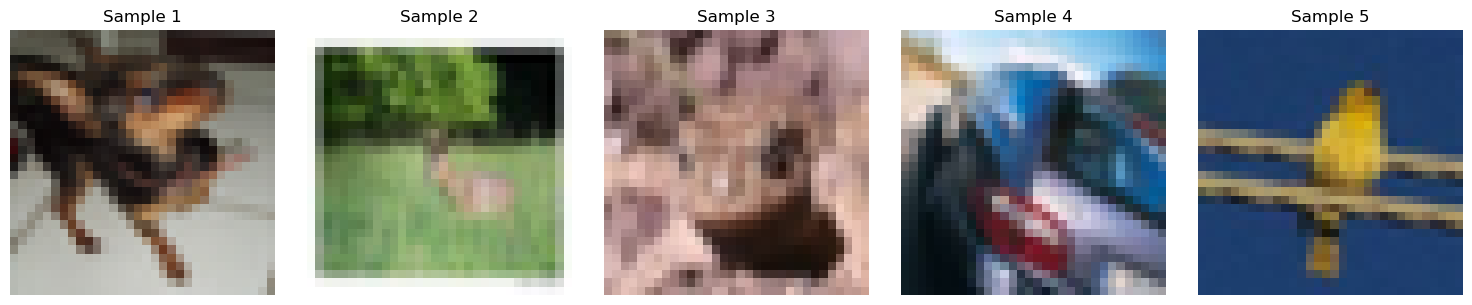

In [12]:
# ------------------------------------------------------------
# Show a few raw CIFAR-10 samples so the reader knows what
# the inputs look like before we start reconstructing them.
# ------------------------------------------------------------
def show_images(images, titles=None, cols=5):
    plt.figure(figsize=(15, 3))
    for i, img in enumerate(images[:cols]):
        plt.subplot(1, cols, i + 1)
        plt.imshow(np.transpose(img.numpy(), (1, 2, 0)))
        plt.axis("off")
        if titles is not None:
            plt.title(titles[i])
    plt.tight_layout()
    plt.show()

show_images(sample_batch[:5], titles=[f"Sample {i+1}" for i in range(5)])

In [13]:
# ------------------------------------------------------------
# Training loop
# ------------------------------------------------------------
# This loop mirrors the paper's recipe at miniature scale:
#   - AdamW optimizer with decoupled weight decay   [1, App. A.1]
#   - Linear warmup followed by cosine decay        [1, Sec. 3.5, App. A.1]
#   - Per-patch-normalized pixel targets            [1, Table 1d]
# Everything is small enough to run on a laptop CPU, but each
# training-section decision we explained in 3.4–3.6 now actually
# participates in the update step instead of only being discussed.

model = MiniMAE(norm_pix_loss=NORM_PIX_LOSS).to(device)

# AdamW = Adam with decoupled weight decay [1, App. A.1].
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    betas=(0.9, 0.95),        # paper uses (0.9, 0.95), not Adam's default
    weight_decay=WEIGHT_DECAY,
)

# --- LR schedule: linear warmup, then cosine decay to ~0 -----
# Implemented as a per-step multiplicative factor on LEARNING_RATE.
steps_per_epoch = len(train_loader)
total_steps     = EPOCHS * steps_per_epoch
warmup_steps    = WARMUP_EPOCHS * steps_per_epoch

def lr_lambda(step):
    if step < warmup_steps:
        return step / max(1, warmup_steps)
    progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
    return 0.5 * (1.0 + math.cos(math.pi * progress))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

loss_history = []
lr_history   = []
global_step  = 0
for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    for images, _ in train_loader:
        images = images.to(device)
        optimizer.zero_grad()
        loss, _, _ = model(images)
        loss.backward()
        optimizer.step()
        scheduler.step()                              # per-step warmup+cosine
        lr_history.append(optimizer.param_groups[0]["lr"])
        running_loss += loss.item()
        global_step += 1
    avg_loss = running_loss / len(train_loader)
    loss_history.append(avg_loss)
    print(f"Epoch {epoch + 1}/{EPOCHS} | loss = {avg_loss:.4f} "
          f"| lr = {optimizer.param_groups[0]['lr']:.2e}")

Epoch 1/5 | loss = 0.9275 | lr = 1.00e-03
Epoch 2/5 | loss = 0.8103 | lr = 8.54e-04
Epoch 3/5 | loss = 0.7854 | lr = 5.00e-04
Epoch 4/5 | loss = 0.7700 | lr = 1.46e-04
Epoch 5/5 | loss = 0.7582 | lr = 0.00e+00


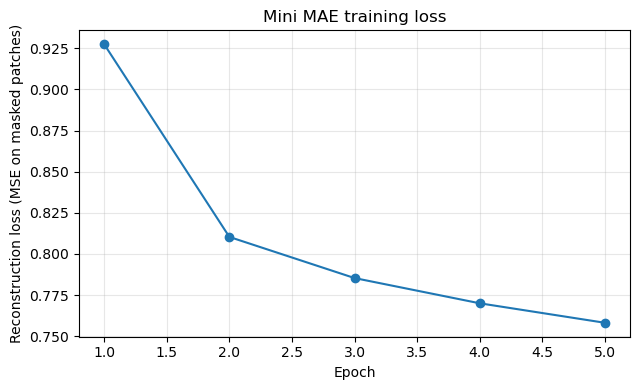

In [14]:
# ------------------------------------------------------------
# Training curve
# ------------------------------------------------------------
# A small but informative sanity check: the loss should decrease
# monotonically for the first few epochs, which confirms that the
# encoder/decoder are cooperating to reconstruct masked patches.
plt.figure(figsize=(6.5, 4))
plt.plot(range(1, EPOCHS + 1), loss_history, marker="o", color="#1f77b4")
plt.xlabel("Epoch")
plt.ylabel("Reconstruction loss (MSE on masked patches)")
plt.title("Mini MAE training loss")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

What you should see: the loss starts near 1.0, which is roughly the variance of a unit-normalized patch, i.e. what you'd expect from random predictions and drops steadily to around 0.75 over the five epochs. (Because norm_pix_loss=True, the target is z-scored per patch, so these numbers live on a different scale than an MSE on raw [0,1] pixels would; a comparable run with norm_pix_loss=False would show the same downward shape but with losses an order of magnitude smaller.) That downward trajectory is the simplest possible evidence that the model is learning, at initialization it is predicting near-random pixels; after a few epochs it is producing values that actually correlate with the hidden content.

## 3.10 Reconstructions — What the Model Has Actually Learned

A loss curve going down is encouraging, but *looking* at the reconstructions is what makes the paper feel real. The paper's Figure 2 shows triplets of (masked input, reconstruction, ground truth) and argues that the reconstructions are semantically plausible even when they differ from the ground truth.

Two notes on the visualization convention:

- Following the paper's Figure 2 caption, we keep the *visible* patches unchanged and only overlay the *predicted* patches at masked positions. The decoder does produce an output at visible positions, but since the loss never touched them, those outputs are not meaningful and would just look like noise.
- We clamp to `[0, 1]` before plotting so `imshow` renders cleanly.

Our model is tiny and trained for a few epochs on 5 000 images — we are not trying to compete with Figure 2 of the paper, we are trying to show the same mechanism producing some kind of reasonable output.

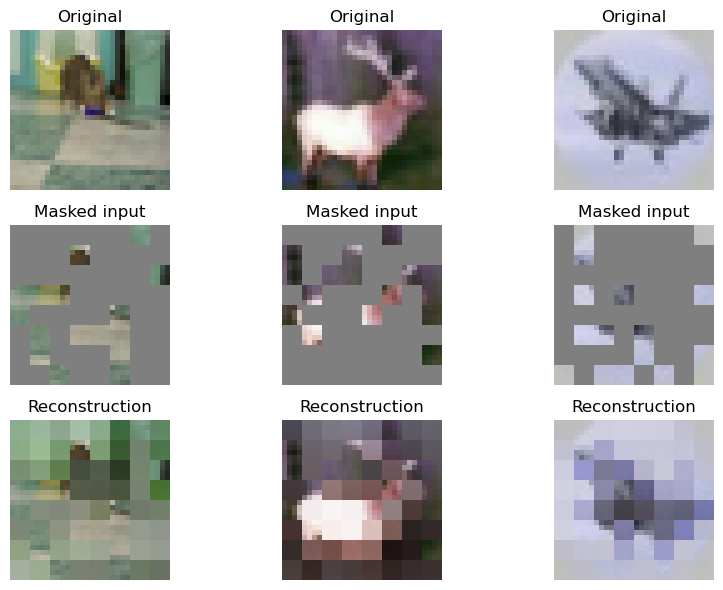

In [15]:
# ------------------------------------------------------------
# Build original / masked / reconstruction triplets for display.
# ------------------------------------------------------------
# The reconstruction column uses the paper's Figure 2 convention:
# real pixels at visible positions, predicted pixels at masked positions.

def build_reconstruction_triplet(images, pred_patches, mask,
                                 patch_size=PATCH_SIZE):
    original = images.detach().cpu()
    B = original.shape[0]

    original_patches = patchify(original)
    pred_patches_cpu = pred_patches.detach().cpu()
    mask_cpu = mask.detach().cpu()

    # If the model was trained with norm_pix_loss, predictions are in
    # z-scored pixel space. Invert the z-score per patch using the
    # original patch statistics so the overlay sits on the same scale
    # as the visible pixels.
    if getattr(model, "norm_pix_loss", False):
        mean = original_patches.mean(dim=-1, keepdim=True)
        var  = original_patches.var(dim=-1, keepdim=True, unbiased=False)
        pred_patches_cpu = pred_patches_cpu * (var + 1e-6).sqrt() + mean

    # Overlay: visible keeps original, masked gets predicted.
    m = mask_cpu.unsqueeze(-1)
    overlay = original_patches * (1 - m) + pred_patches_cpu * m
    reconstruction = unpatchify(overlay).clamp(0.0, 1.0)

    masked_inputs = torch.stack([
        apply_patch_mask_to_image(original[i], mask_cpu[i])
        for i in range(B)
    ], dim=0).clamp(0.0, 1.0)

    return original.clamp(0.0, 1.0), masked_inputs, reconstruction


model.eval()
with torch.no_grad():
    eval_images, _ = next(iter(train_loader))
    eval_images = eval_images[:6].to(device)
    _, pred_patches, mask = model(eval_images)

original, masked_inputs, reconstructed = build_reconstruction_triplet(
    eval_images, pred_patches, mask
)

n_examples = 3
plt.figure(figsize=(9, 6))
for i in range(n_examples):
    plt.subplot(3, n_examples, i + 1)
    plt.imshow(np.transpose(original[i].numpy(), (1, 2, 0)))
    plt.title("Original"); plt.axis("off")
    plt.subplot(3, n_examples, i + 1 + n_examples)
    plt.imshow(np.transpose(masked_inputs[i].numpy(), (1, 2, 0)))
    plt.title("Masked input"); plt.axis("off")
    plt.subplot(3, n_examples, i + 1 + 2 * n_examples)
    plt.imshow(np.transpose(reconstructed[i].numpy(), (1, 2, 0)))
    plt.title("Reconstruction"); plt.axis("off")

plt.tight_layout()
plt.show()

The reconstructions are blurry, but the important property is that the predicted patches *respect* the visible ones — colors and low-frequency structure continue across patch boundaries, which means the encoder is using the visible tokens to inform what the masked ones should look like. That is the exact behavior the paper demonstrates at much larger scale in Figure 2 [1, Fig. 2], just at CIFAR-10 resolution with five epochs of training.

### A Small Masking-Ratio Ablation

To close this section with something empirical, we run a miniature version of the paper's Figure 5 ablation: train three short models at 50%, 75%, and 90% masking, and compare final training losses. This is not meant to reproduce the paper's linear-probing accuracy curves — we have no downstream task plugged in — but it does show how dramatically the difficulty of the self-supervised task changes with the ratio.

  mask ratio 0.50  →  final training loss 0.8124
  mask ratio 0.75  →  final training loss 0.8253
  mask ratio 0.90  →  final training loss 0.8413


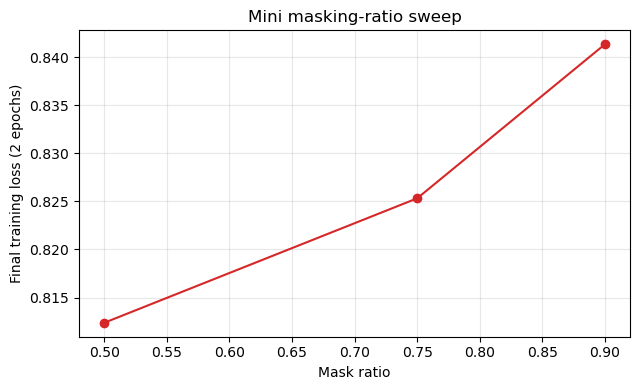

In [16]:
# ------------------------------------------------------------
# Tiny masking-ratio ablation
# ------------------------------------------------------------
# Each model is trained for 2 epochs on the same subset; we only
# compare final-epoch training losses. This is a qualitative
# reproduction of the spirit of [1, Fig. 5], not of its numbers.

def train_one_ratio(mask_ratio, epochs=2):
    m = MiniMAE(mask_ratio=mask_ratio, norm_pix_loss=NORM_PIX_LOSS).to(device)
    opt = torch.optim.AdamW(
        m.parameters(),
        lr=LEARNING_RATE,
        betas=(0.9, 0.95),
        weight_decay=WEIGHT_DECAY,
    )
    last = None
    m.train()
    for epoch in range(epochs):
        running = 0.0
        for images, _ in train_loader:
            images = images.to(device)
            opt.zero_grad()
            loss, _, _ = m(images)
            loss.backward()
            opt.step()
            running += loss.item()
        last = running / len(train_loader)
    return last


mask_ratios = [0.50, 0.75, 0.90]
ablation = {}
for r in mask_ratios:
    final_loss = train_one_ratio(r, epochs=2)
    ablation[r] = final_loss
    print(f"  mask ratio {r:.2f}  →  final training loss {final_loss:.4f}")

plt.figure(figsize=(6.5, 4))
plt.plot(list(ablation.keys()), list(ablation.values()),
         marker="o", color="#d62728")
plt.xlabel("Mask ratio")
plt.ylabel("Final training loss (2 epochs)")
plt.title("Mini masking-ratio sweep")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The training loss naturally grows with the mask ratio: a model asked to predict 90% of the image has a harder problem than one asked to predict 50%. Training loss by itself is not a representation-quality metric (lower loss does *not* mean better features), but it confirms that the masking ratio meaningfully changes the task the model is solving. The paper's full story — that 75% is the representation-quality sweet spot — requires a downstream classifier to measure, which is beyond the scope of this MWE.

## 3.11 Why Mask Tokens Go in the Decoder, Not the Encoder — a Live Timing Demo

The last thing worth demonstrating is the efficiency claim at the heart of MAE's asymmetric design. Table 1c and Table 2 of the paper report that feeding mask tokens through the encoder (instead of leaving them to the decoder) costs 3.3× more FLOPs and 2.8–4.1× more wall-clock time [1, Table 1c, Table 2]. That is the primary reason MAE can afford to train such big encoders.

We cannot reproduce the accuracy numbers on CIFAR-10 in a few epochs, but the efficiency effect is a pure computational phenomenon — it should show up on any machine. We build a symmetric variant of our MiniMAE in which the encoder processes all 64 tokens (masked positions filled with a learned mask token) and time a forward pass against our asymmetric version.

In [17]:
# ------------------------------------------------------------
# MiniMAE_Symmetric
# ------------------------------------------------------------
# Same capacity as MiniMAE, but the encoder receives ALL tokens,
# with masked positions replaced by a learned mask token. This is
# the "encoder w/ [M]" row in Table 1c of [1].

class MiniMAE_Symmetric(nn.Module):
    def __init__(self):
        super().__init__()
        self.patch_embed = nn.Linear(PATCH_DIM, EMBED_DIM)
        self.pos_embed = nn.Parameter(
            torch.randn(1, NUM_PATCHES, EMBED_DIM) * 0.02)
        self.encoder_mask_token = nn.Parameter(
            torch.zeros(1, 1, EMBED_DIM))
        self.encoder_blocks = nn.ModuleList([
            TransformerBlock(EMBED_DIM, NUM_HEADS)
            for _ in range(ENCODER_DEPTH)
        ])
        self.encoder_norm = nn.LayerNorm(EMBED_DIM)

        self.decoder_embed = nn.Linear(EMBED_DIM, DECODER_EMBED_DIM)
        self.decoder_pos_embed = nn.Parameter(
            torch.randn(1, NUM_PATCHES, DECODER_EMBED_DIM) * 0.02)
        self.decoder_blocks = nn.ModuleList([
            TransformerBlock(DECODER_EMBED_DIM, NUM_HEADS)
            for _ in range(DECODER_DEPTH)
        ])
        self.decoder_norm = nn.LayerNorm(DECODER_EMBED_DIM)
        self.decoder_pred = nn.Linear(DECODER_EMBED_DIM, PATCH_DIM)

    def forward(self, images):
        patches = patchify(images)
        x = self.patch_embed(patches) + self.pos_embed  # [B, 64, 128]

        # Build the same kind of mask used in the asymmetric model,
        # then REPLACE masked positions with a learned mask token
        # before the encoder runs. The encoder now processes all 64.
        _, mask, _, _ = random_masking(x, MASK_RATIO)
        m = mask.unsqueeze(-1)
        x = x * (1 - m) + self.encoder_mask_token.expand_as(x) * m

        for block in self.encoder_blocks:
            x = block(x)
        x = self.encoder_norm(x)

        x = self.decoder_embed(x) + self.decoder_pos_embed
        for block in self.decoder_blocks:
            x = block(x)
        x = self.decoder_norm(x)
        pred = self.decoder_pred(x)

        loss = ((pred - patches) ** 2).mean(dim=-1)
        loss = (loss * mask).sum() / mask.sum()
        return loss, pred, mask


def time_forward(model, n_iters=20, batch_size=BATCH_SIZE):
    model.eval()
    dummy = torch.rand(batch_size, IN_CHANNELS, IMAGE_SIZE, IMAGE_SIZE)
    with torch.no_grad():
        for _ in range(3):       # warmup
            _ = model(dummy)
    start = time.perf_counter()
    with torch.no_grad():
        for _ in range(n_iters):
            _ = model(dummy)
    return (time.perf_counter() - start) / n_iters


def count_params(m):
    return sum(p.numel() for p in m.parameters())


asym = MiniMAE().to(device)
sym  = MiniMAE_Symmetric().to(device)

asym_t = time_forward(asym)
sym_t  = time_forward(sym)

print(f"Asymmetric (encoder sees 16 visible tokens): "
      f"{count_params(asym):>8,} params | {asym_t * 1000:6.2f} ms / forward")
print(f"Symmetric  (encoder sees all 64 w/ mask tk): "
      f"{count_params(sym):>8,} params | {sym_t * 1000:6.2f} ms / forward")
print(f"Speedup from keeping mask tokens out of the encoder: "
      f"{sym_t / asym_t:.2f}×")
print()
print("Table 2 of [1] reports 2.8× to 4.1× wall-clock speedup on TPU for")
print("ViT-L and ViT-H. On CPU at this tiny scale the speedup is smaller")
print("because absolute times are dominated by Python and PyTorch overhead,")
print("but the direction is the same: shorter encoder sequence = faster model.")

Asymmetric (encoder sees 16 visible tokens):  658,416 params |  21.69 ms / forward
Symmetric  (encoder sees all 64 w/ mask tk):  658,448 params |  31.29 ms / forward
Speedup from keeping mask tokens out of the encoder: 1.44×

Table 2 of [1] reports 2.8× to 4.1× wall-clock speedup on TPU for
ViT-L and ViT-H. On CPU at this tiny scale the speedup is smaller
because absolute times are dominated by Python and PyTorch overhead,
but the direction is the same: shorter encoder sequence = faster model.


The measured speedup on a laptop CPU is modest because at this scale Python and PyTorch overhead dominate, but the direction is unambiguous and matches the paper. At ImageNet scale with ViT-Large and ViT-Huge encoders, the same computational asymmetry produces the 2.8–4.1× wall-clock speedups reported in Table 2 [1, Table 2]. That speedup is the reason MAE can afford to train enormous encoders for 1600 epochs on hardware that would otherwise melt — and in turn it is why MAE's accuracy curves keep climbing where contrastive methods saturate.

## 3.12 Where We End Up

The notebook now contains, in one place:

- The motivation for MAE and the three reasons earlier vision-masking attempts underperformed (Part 1).
- A complete mini re-implementation of the architecture, with every tensor shape shown (Part 2).
- A training loop with the paper's design decisions explained one at a time, plus a live CPU run on CIFAR-10 that reproduces the qualitative behavior: the loss drops, the reconstructions become structured, higher masking ratios make the task harder, and removing mask tokens from the encoder speeds the model up (Part 3).

This is the core of MAE. The remaining parts of the project — a discussion of the model's limitations and future directions, and the group's breakdown of contributions — are covered in the next sections of the document.

---

## References

The numbered citations used throughout this notebook refer to the entries below.

**[1]** He, K., Chen, X., Xie, S., Li, Y., Dollár, P., and Girshick, R. (2022). *Masked Autoencoders Are Scalable Vision Learners.* Proceedings of the IEEE/CVF Conference on Computer Vision and Pattern Recognition (CVPR), pp. 16000–16009. The primary paper being annotated.

**[2]** Dosovitskiy, A., Beyer, L., Kolesnikov, A., Weissenborn, D., Zhai, X., Unterthiner, T., Dehghani, M., Minderer, M., Heigold, G., Gelly, S., Uszkoreit, J., and Houlsby, N. (2021). *An Image is Worth 16×16 Words: Transformers for Image Recognition at Scale.* International Conference on Learning Representations (ICLR). The Vision Transformer that MAE's encoder is based on.

**[3]** Vaswani, A., Shazeer, N., Parmar, N., Uszkoreit, J., Jones, L., Gomez, A. N., Kaiser, L., and Polosukhin, I. (2017). *Attention Is All You Need.* Advances in Neural Information Processing Systems (NeurIPS). The original Transformer block reused inside both the encoder and the decoder.

**[4]** Devlin, J., Chang, M.-W., Lee, K., and Toutanova, K. (2019). *BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding.* Proceedings of NAACL-HLT 2019. The masked-prediction pre-training objective MAE adapts to images.

**[5]** Krizhevsky, A. (2009). *Learning Multiple Layers of Features from Tiny Images.* Technical Report, University of Toronto. The CIFAR-10 dataset used for the MWE, accessed via `torchvision.datasets.CIFAR10`.

**[6]** Paszke, A., Gross, S., Massa, F., Lerer, A., Bradbury, J., Chanan, G., et al. (2019). *PyTorch: An Imperative Style, High-Performance Deep Learning Library.* Advances in Neural Information Processing Systems (NeurIPS). The framework used for all model code in this notebook.

**[7]** Loshchilov, I., and Hutter, F. (2019). *Decoupled Weight Decay Regularization.* International Conference on Learning Representations (ICLR). The AdamW optimizer used by MAE at full scale.

**[8]** Vincent, P., Larochelle, H., Bengio, Y., and Manzagol, P.-A. (2008). *Extracting and Composing Robust Features with Denoising Autoencoders.* Proceedings of the 25th International Conference on Machine Learning (ICML). The classical denoising autoencoder framework that MAE generalizes.

**[9]** Loshchilov, I., and Hutter, F. (2017). *SGDR: Stochastic Gradient Descent with Warm Restarts.* International Conference on Learning Representations (ICLR). Source of the cosine learning rate schedule used by MAE.

**[30]** Huang, G., Sun, Y., Liu, Z., Sedra, D., and Weinberger, K. Q. (2016). *Deep Networks with Stochastic Depth.* European Conference on Computer Vision (ECCV). The stochastic depth regularizer used by the paper's full-scale training recipe.

**[Code and implementation references]** This notebook was informed by public MAE implementation resources, including Facebook Research’s official MAE PyTorch implementation, Hugging Face’s ViTMAE model documentation, and LightlySSL’s educational MAE self-supervised learning example. These references were consulted to understand the standard shuffle/unshuffle masking convention, the use of variables such as `ids_restore` and `ids_keep`, and the asymmetric encoder-decoder layout used in MAE-style models. All code in this notebook was written as a simplified, readable, CPU-friendly educational implementation rather than a direct reproduction of any full-scale repository.

Facebook Research. *Masked Autoencoders: A PyTorch Implementation.*  
https://github.com/facebookresearch/mae

Hugging Face Transformers. *ViTMAE model documentation / implementation reference.*  
https://huggingface.co/docs/transformers/model_doc/vit_mae

LightlySSL Documentation. *MAE self-supervised learning example.*  
https://docs.lightly.ai/self-supervised-learning/examples/mae.html